## Reading and Loading the data  
---
Reading and understanding the datasets

In [1]:
# Libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from wordcloud import WordCloud



In [2]:
# loading datasets
data = pd.read_csv('../datasets/data.csv')
genre_data = pd.read_csv('../datasets/data_by_genres.csv')
year_data = pd.read_csv('../datasets/data_by_year.csv')
artist_data = pd.read_csv('../datasets/data_by_artist.csv')

In [3]:
#2 rows of the data
data.head(2)

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936


In [4]:
#2 rows of the genre data
genre_data.head(2)

,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.3616,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.1310,-16.854000,0.076817,120.285667,0.221750,52.500000,5


In [5]:
#2 rows of the year data
year_data.head(2)

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.20571,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.24072,-19.275282,0.116655,100.884521,0.535549,0.140845,10


In [6]:
#2 rows of the artist data
artist_data.head(2)

,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690,0.176212,103.044154,0.268865,30.576923,5


In [7]:
#dataset info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  str    
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  str    
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  str    
 15  popularity        170653 non-null  int64  
 16  release_date      170653 non-nu

In [8]:
#genreinfo
genre_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2973 entries, 0 to 2972
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mode              2973 non-null   int64  
 1   genres            2973 non-null   str    
 2   acousticness      2973 non-null   float64
 3   danceability      2973 non-null   float64
 4   duration_ms       2973 non-null   float64
 5   energy            2973 non-null   float64
 6   instrumentalness  2973 non-null   float64
 7   liveness          2973 non-null   float64
 8   loudness          2973 non-null   float64
 9   speechiness       2973 non-null   float64
 10  tempo             2973 non-null   float64
 11  valence           2973 non-null   float64
 12  popularity        2973 non-null   float64
 13  key               2973 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 325.3 KB


In [9]:
# creating a decade column
data['decade'] = data['year'].apply(lambda x: f"{(x//10)*10}s")

## Explanatory Data Analysis
---


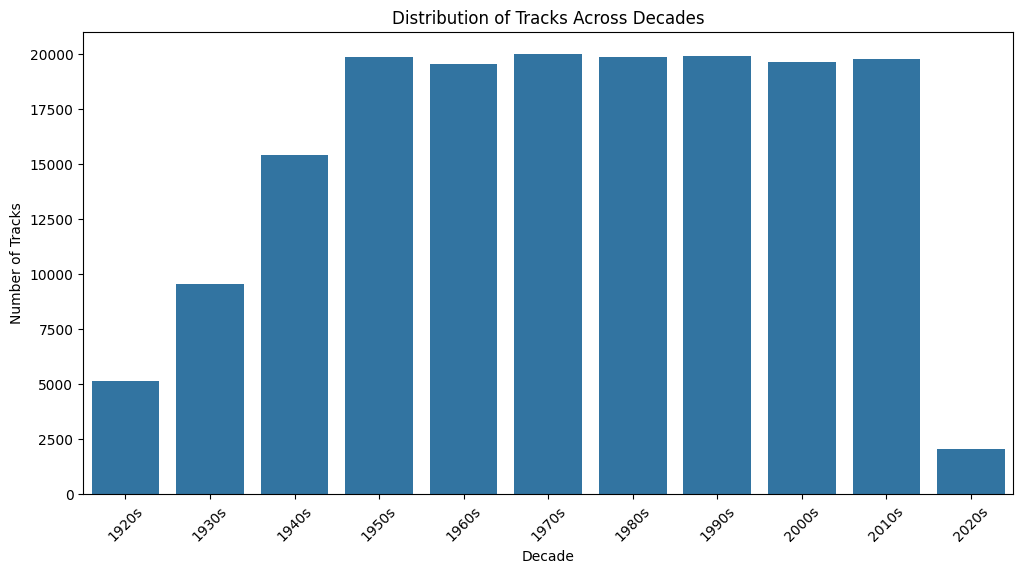

In [10]:
#Countplot of Tracks across Decades
plt.figure(figsize=(12,6))

sns.countplot(x=data['decade'], order=sorted(data['decade'].unique()))

plt.title('Distribution of Tracks Across Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')

plt.xticks(rotation=45)

plt.show()

In [11]:
#Plot Trends of Sound Features Over Decades
import plotly.express as px
sound_features = [
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'valence'
]

fig = px.line(
    year_data,
    x='year',
    y=sound_features,
    title='Trend of Various Sound Features Over Decades'
)

fig.show()

In [13]:
#plot the trend of loudness over time using year_data:
fig = px.line(
    year_data,
    x='year',
    y='loudness',
    title='Trend of Loudness Over Decades'
)

fig.show()

In [14]:
# Top 10 Genres by Average Popularity
top10_genres = genre_data.nlargest(10, 'popularity')

In [15]:
#Plot Audio Features for the Top 10 Genres
fig = px.bar(
    top10_genres,
    x='genres',
    y=['valence', 'energy', 'danceability', 'acousticness'],
    barmode='group',
    title='Trend of Various Sound Features Over Top 10 Genres'
)

fig.show()

In [17]:
#importing wordcloud
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [19]:
# Generate genre word cloud
comment_words = ' '.join(genre_data['genres'].astype(str))

stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    max_words=40,
    min_font_size=10
).generate(comment_words)

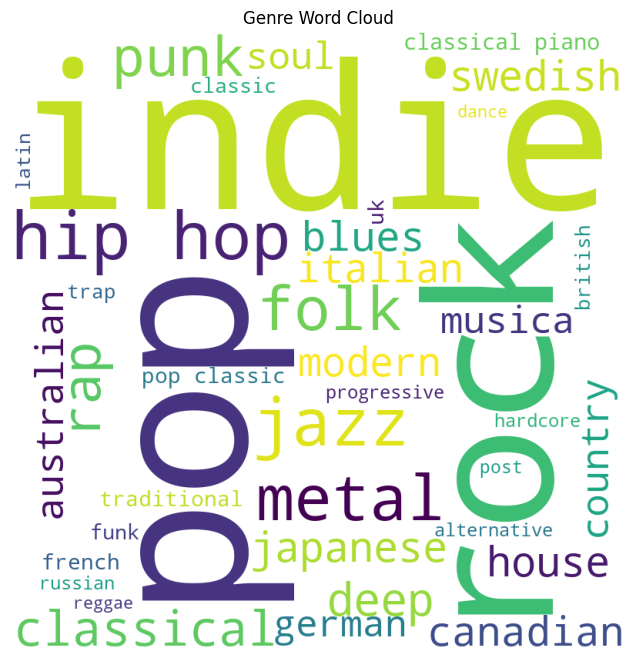

In [20]:
# Display Genre Word Cloud
plt.figure(figsize=(8,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Genre Word Cloud")
plt.show()

In [21]:
#Generate Artist Word Cloud
comment_words = ' '.join(artist_data['artists'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    min_word_length=3,
    max_words=40,
    min_font_size=10
).generate(comment_words)

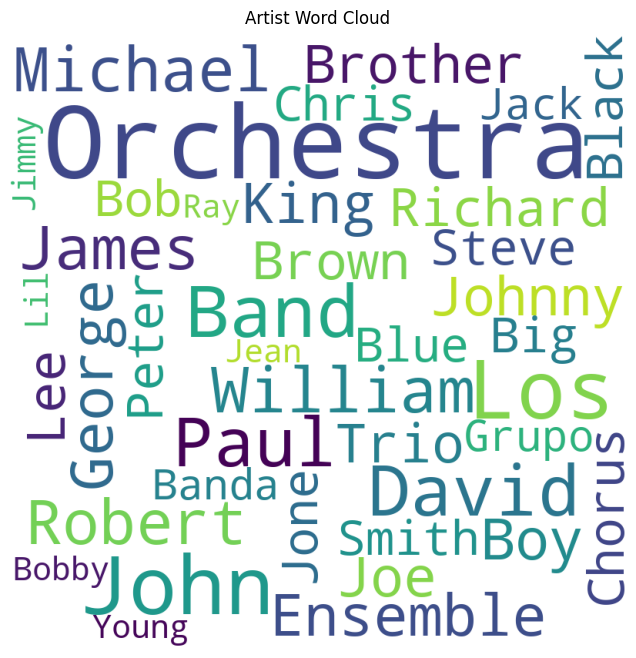

In [25]:
# Display Artist Word Cloud
plt.figure(figsize=(8,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Artist Word Cloud")
plt.show()

In [26]:
#Top 10 Artists with Most Songs Produced
top10_most_song_produced_artists = (
    artist_data[['artists', 'count']]
    .sort_values('count', ascending=False)
    .head(10)
)

top10_most_song_produced_artists

,artists,count
8367,Francisco Canaro,3169
28561,Эрнест Хемингуэй,2422
28560,Эрих Мария Ремарк,2136
8434,Frank Sinatra,1459
10714,Ignacio Corsini,1256
27109,Vladimir Horowitz,1200
1682,Arturo Toscanini,1146
2707,Billie Holiday,1103
12378,Johnny Cash,1061
7426,Elvis Presley,1023


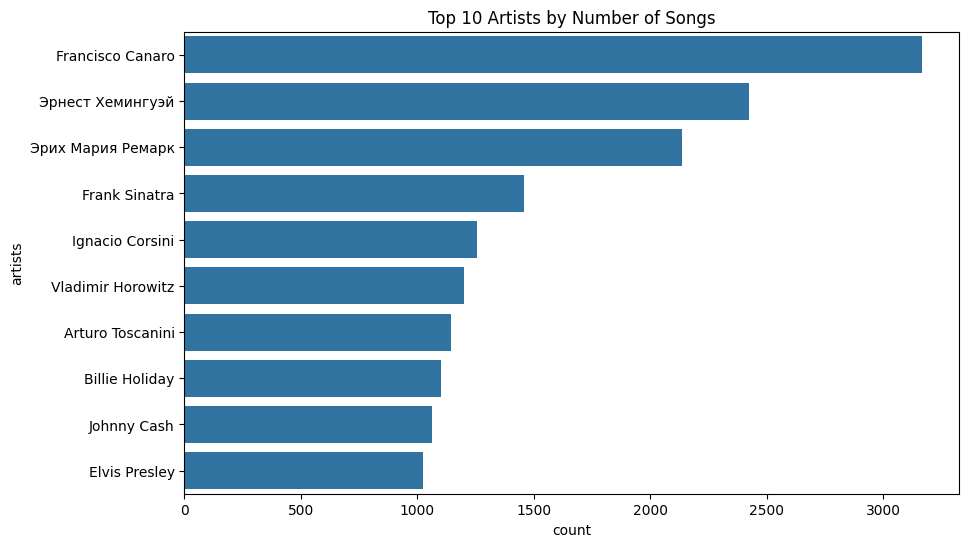

In [27]:
# visualize the top 10 artists with most songs produced
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_most_song_produced_artists,
    x='count',
    y='artists'
)

plt.title('Top 10 Artists by Number of Songs')
plt.show()

In [28]:
#Top 10 Most Popular Artists
top10_popular_artists = (
    artist_data[['artists', 'popularity']]
    .sort_values('popularity', ascending=False)
    .head(10)
)

top10_popular_artists

,artists,popularity
20966,Ritt Momney,93.0
14354,Lele Pons,92.0
15070,Los Legendarios,90.0
11764,Jerry Di,89.0
7463,Emilee,88.0
28263,salem ilese,88.0
23687,Surf Mesa,88.0
213,A7S,87.0
14378,Lenny Santos,86.0
16453,Master KG,86.0


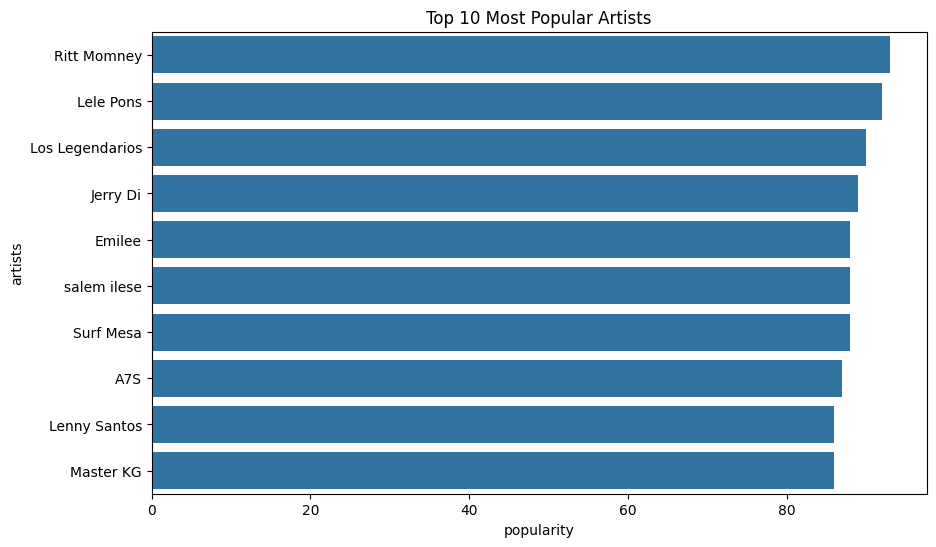

In [29]:
# visualize the top 10 most popular artists
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_popular_artists,
    x='popularity',
    y='artists'
)

plt.title('Top 10 Most Popular Artists')
plt.show()